# Final AFT workflow — reuse existing KM event checkpoints

This workflow **does not rerun shock detection, basis-resolution outcomes, Kaplan–Meier fitting, or KM plots**.

It reads the existing v6 event-level KM checkpoints from `event_store/spot` and `event_store/perp`, treats `start_ts`, `prev_ts`, `Length`, and `Status` as immutable, reloads raw trades only to reconstruct the original event-time rows, then recalculates the corrected leakage-safe covariates and AFT models.

In [11]:
from pathlib import Path
import pandas as pd

from survival_analysis_pipeline_final import (
    DEFAULT_AFT_COVARIATES,
    DEFAULT_MARKETS,
    FINAL_BASE_AFT_DIR,
    FINAL_LIQUIDITY_AFT_DIR,
    FINAL_AFT_RESULTS_DIR,
    KM_REUSE_VERSION,
    run_market_pipeline_from_saved_km,
)
from survival_analysis_utils_final import (
    COVARIATE_TIMING_VERSION,
    LIQUIDITY_TIMING_VERSION,
    PIPELINE_VERSION,
)

print("Pipeline:", PIPELINE_VERSION)
print("KM reuse:", KM_REUSE_VERSION)
print("Base timing:", COVARIATE_TIMING_VERSION)
print("Liquidity timing:", LIQUIDITY_TIMING_VERSION)

Pipeline: survival_analysis_final_v2_reuse_km
KM reuse: v5_monthly_km_events_read_only_final_v2
Base timing: prior_day_strict_pre_shock_5min_final_v1
Liquidity timing: strict_pre_shock_metric_final_v1


## 1. Point each market at the existing KM checkpoint root

The default assumes your old v6 folders are `./sa_btc_um`, `./sa_btc_cm`, `./sa_eth_um`, and `./sa_eth_cm`, with saved episode files under:

- `event_store/spot/*.parquet`
- `event_store/perp/*.parquet`

If your old KM checkpoint root is somewhere else, change only `km_checkpoint_dir` below. **Do not point this at `aft_data`; it needs the saved KM event checkpoints.**

In [14]:
START_DATE = "20210101"
END_DATE = "20260101"  # exclusive

MARKETS = {name: dict(cfg) for name, cfg in DEFAULT_MARKETS.items()}

# Example if an old KM store is elsewhere:
# MARKETS["btc_um"]["km_checkpoint_dir"] = Path(r"D:/thesis/sa_btc_um")

SELECTED_MARKETS = ["btc_um", "btc_cm", "eth_um", "eth_cm"]
# SELECTED_MARKETS = ["eth_cm"]
AFT_COVARIATES = list(DEFAULT_AFT_COVARIATES)

PRIMARY_RESOLUTION_PCT = 90
LOAD_LOOKBACK_DAYS = 1
LOAD_FOLLOWUP_DAYS = 1

RESUME = True
OVERWRITE_AUGMENTED = False
REDOWNLOAD_METRICS = False
OVERWRITE_RESULTS = True
MIN_COMPLETE_OBSERVATIONS = 100

for name in SELECTED_MARKETS:
    cfg = MARKETS[name]
    print(name, "KM input:", cfg["km_checkpoint_dir"], "AFT output:", cfg["run_dir"])

btc_um KM input: sa_btc_um AFT output: sa_btc_um
btc_cm KM input: sa_btc_cm AFT output: sa_btc_cm
eth_um KM input: sa_eth_um AFT output: sa_eth_um
eth_cm KM input: sa_eth_cm AFT output: sa_eth_cm


## 2. Reuse KM episodes and rerun only corrected AFT covariates/fits

For every saved source chunk, the code:

1. reads the old KM episode rows;
2. reloads that chunk's raw trades;
3. rebuilds the same irregular forward-filled event-time stream;
4. reconstructs `event_tick` from saved `start_ts`;
5. asserts saved `prev_ts == tick-1`;
6. calculates corrected pre-shock covariates;
7. asserts `Length` and `Status` are unchanged;
8. writes only new AFT outputs.

It never calls the shock detector or KM fitter.

In [4]:
# outputs = {}

for market_name in SELECTED_MARKETS:
    print("\n" + "#" * 90)
    print("REUSING EXISTING KM:", market_name)
    print("#" * 90)
    # outputs[market_name] = 
    run_market_pipeline_from_saved_km(
        market=MARKETS[market_name],
        start=START_DATE,
        end=END_DATE,
        primary_resolution_pct=PRIMARY_RESOLUTION_PCT,
        load_lookback_days=LOAD_LOOKBACK_DAYS,
        load_followup_days=LOAD_FOLLOWUP_DAYS,
        covariates=AFT_COVARIATES,
        resume=RESUME,
        overwrite_augmented=OVERWRITE_AUGMENTED,
        redownload_metrics=REDOWNLOAD_METRICS,
        overwrite_results=OVERWRITE_RESULTS,
        min_complete_observations=MIN_COMPLETE_OBSERVATIONS,
    )


##########################################################################################
REUSING EXISTING KM: btc_um
##########################################################################################
[skip reused-KM chunk] BTCUSDT um spot 2021-01-01_to_2021-01-18
[skip reused-KM chunk] BTCUSDT um perp 2021-01-01_to_2021-01-18
[skip reused-KM chunk] BTCUSDT um spot 2021-01-18_to_2021-02-01
[skip reused-KM chunk] BTCUSDT um perp 2021-01-18_to_2021-02-01
[skip reused-KM chunk] BTCUSDT um spot 2021-02-01_to_2021-02-18
[skip reused-KM chunk] BTCUSDT um perp 2021-02-01_to_2021-02-18
[skip reused-KM chunk] BTCUSDT um spot 2021-02-18_to_2021-03-01
[skip reused-KM chunk] BTCUSDT um perp 2021-02-18_to_2021-03-01
[skip reused-KM chunk] BTCUSDT um spot 2021-03-01_to_2021-03-18
[skip reused-KM chunk] BTCUSDT um perp 2021-03-01_to_2021-03-18
[skip reused-KM chunk] BTCUSDT um spot 2021-03-18_to_2021-04-01
[skip reused-KM chunk] BTCUSDT um perp 2021-03-18_to_2021-04-01
[skip reused-KM chunk

MemoryError: Unable to allocate 971. MiB for an array with shape (12, 10609005) and data type object

## 3. Compare AFT distribution fit

These are fits to the **same saved KM outcomes**, with only the covariates regenerated.

In [ ]:
selection = []
for market_name, market_outputs in outputs.items():
    manifest = market_outputs["aft_models"].copy()
    if manifest.empty:
        continue
    manifest["market"] = market_name
    selection.append(manifest)

selection = pd.concat(selection, ignore_index=True) if selection else pd.DataFrame()
if not selection.empty:
    display(
        selection[selection["status"].eq("complete")][
            ["market", "source_file", "model", "AIC", "BIC", "complete_rows", "events"]
        ].sort_values(["market", "source_file", "AIC"])
    )
else:
    print("No completed model rows yet.")

## 4. Audit the saved timing and confirm KM was not refit

In [ ]:
for market_name in SELECTED_MARKETS:
    cfg = MARKETS[market_name]
    run_dir = Path(cfg["run_dir"])
    files = sorted((run_dir / FINAL_LIQUIDITY_AFT_DIR).glob("*.parquet"))
    print("\n", market_name, outputs[market_name]["km_status"].to_dict("records"))
    if not files:
        continue
    sample = pd.read_parquet(files[0])
    cols = [
        "start_ts", "prev_ts", "Length", "Status",
        "covariate_5min_ts", "daily_covariate_date", "create_time",
        "covariate_timing_version", "liquidity_timing_version",
        "km_reuse_version", "km_source_files",
    ]
    print(files[0].name)
    display(sample[[c for c in cols if c in sample.columns]].head())

## 6. Correlation and VIF diagnostics

The primary diagnostic pools a balanced sample across months but keeps each market and shock direction separate. This is more stable than estimating a correlation matrix from each month and avoids allowing high-activity months to dominate. Set `RUN_MONTHLY_VIF = True` for a month-level robustness table.

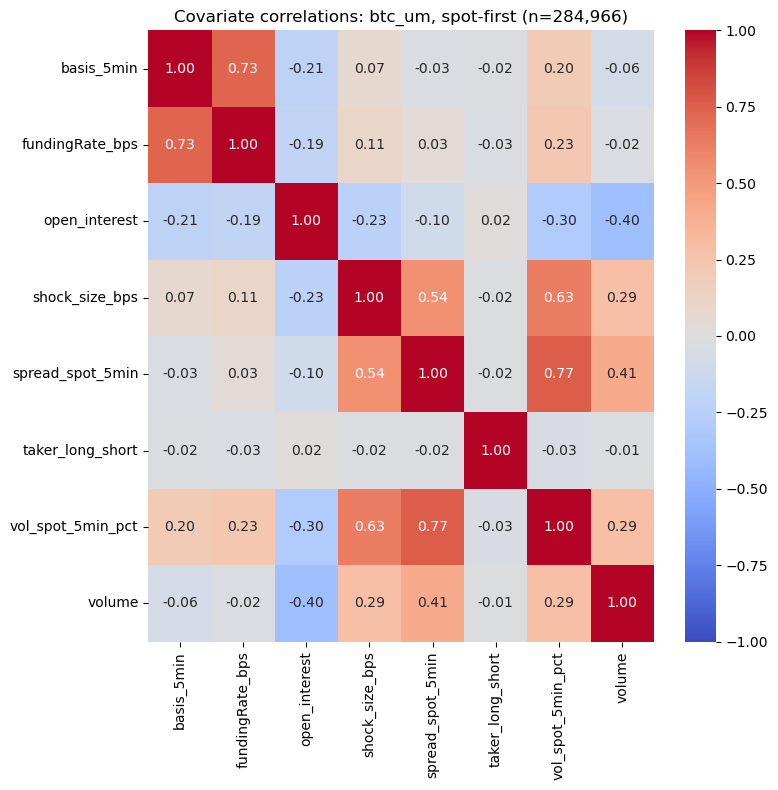

,market,first,covariate,VIF
6,btc_um,spot,vol_spot_5min_pct,3.594338
4,btc_um,spot,spread_spot_5min,3.202074
0,btc_um,spot,basis_5min,2.261029
1,btc_um,spot,fundingRate_bps,2.192585
3,btc_um,spot,shock_size_bps,1.716181
7,btc_um,spot,volume,1.511647
2,btc_um,spot,open_interest,1.448230
5,btc_um,spot,taker_long_short,1.001574


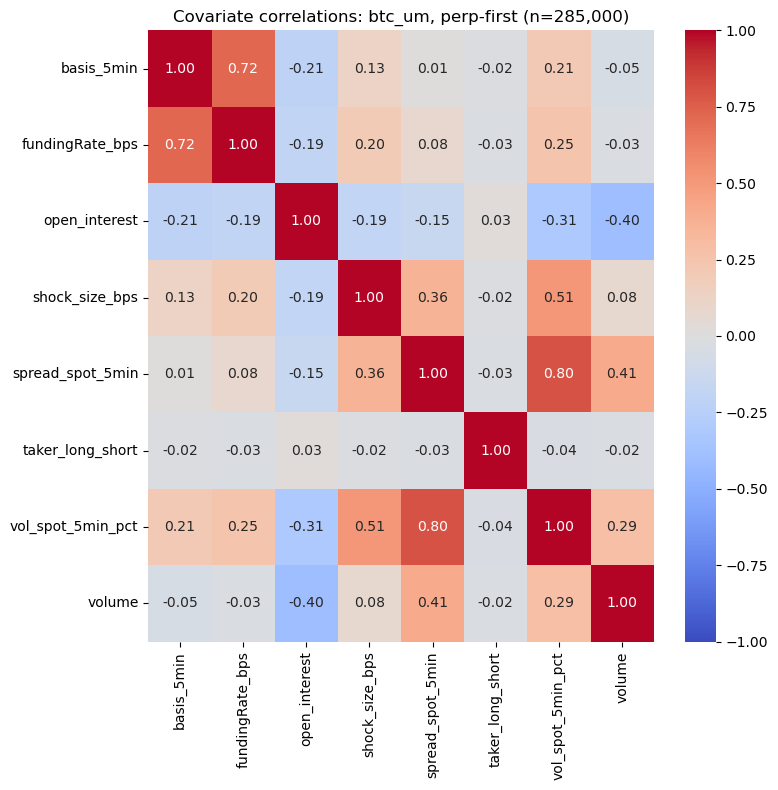

,market,first,covariate,VIF
6,btc_um,perp,vol_spot_5min_pct,4.053782
4,btc_um,perp,spread_spot_5min,3.636449
0,btc_um,perp,basis_5min,2.204925
1,btc_um,perp,fundingRate_bps,2.172998
7,btc_um,perp,volume,1.502683
2,btc_um,perp,open_interest,1.439387
3,btc_um,perp,shock_size_bps,1.379373
5,btc_um,perp,taker_long_short,1.002132


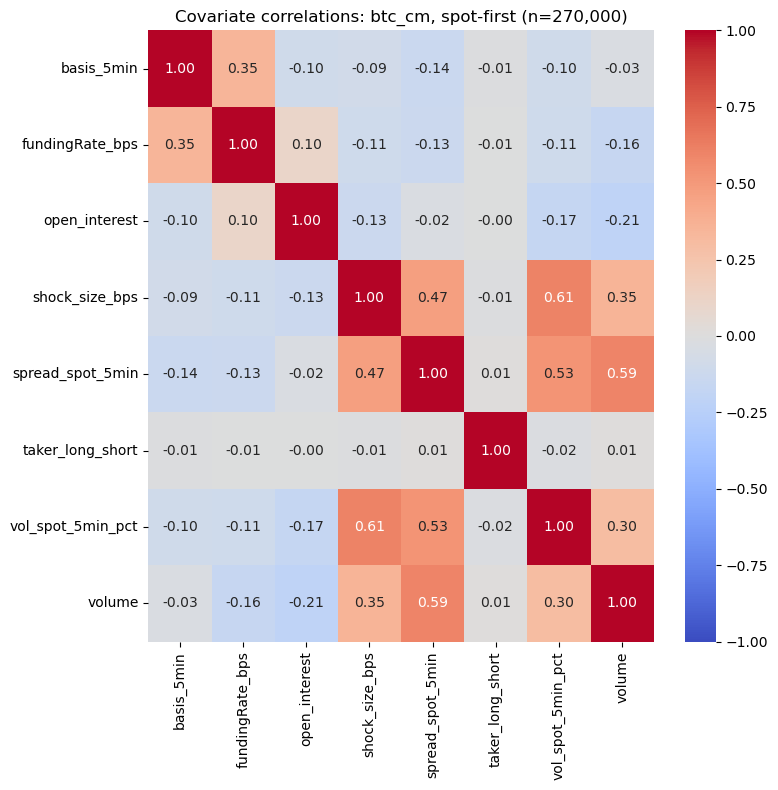

,market,first,covariate,VIF
4,btc_cm,spot,spread_spot_5min,2.073899
6,btc_cm,spot,vol_spot_5min_pct,1.856391
3,btc_cm,spot,shock_size_bps,1.699830
7,btc_cm,spot,volume,1.691723
0,btc_cm,spot,basis_5min,1.183589
1,btc_cm,spot,fundingRate_bps,1.183151
2,btc_cm,spot,open_interest,1.130109
5,btc_cm,spot,taker_long_short,1.001085


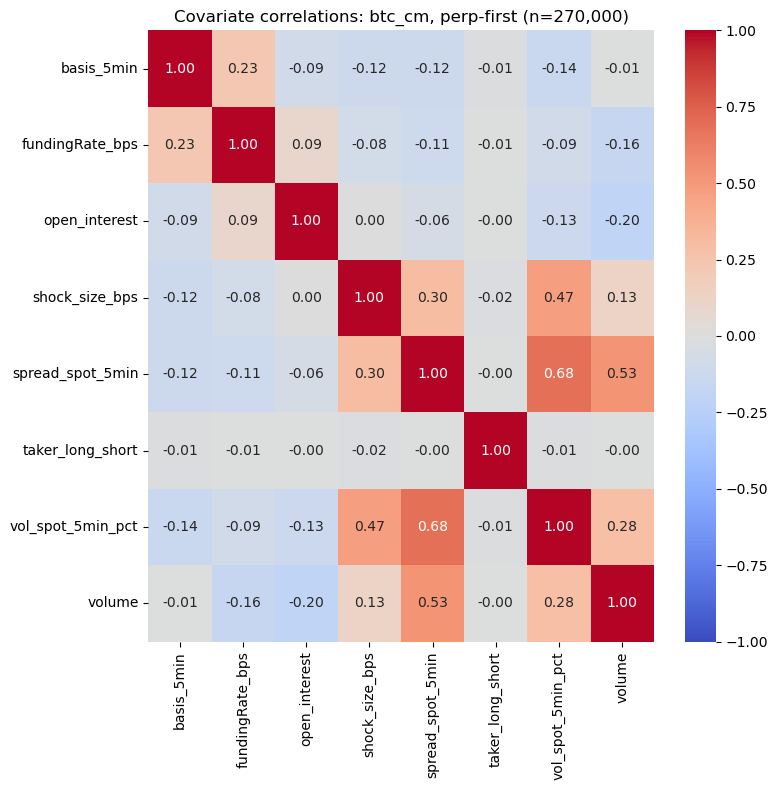

,market,first,covariate,VIF
4,btc_cm,perp,spread_spot_5min,2.495258
6,btc_cm,perp,vol_spot_5min_pct,2.311257
7,btc_cm,perp,volume,1.508143
3,btc_cm,perp,shock_size_bps,1.308638
0,btc_cm,perp,basis_5min,1.098456
2,btc_cm,perp,open_interest,1.096222
1,btc_cm,perp,fundingRate_bps,1.095012
5,btc_cm,perp,taker_long_short,1.000689


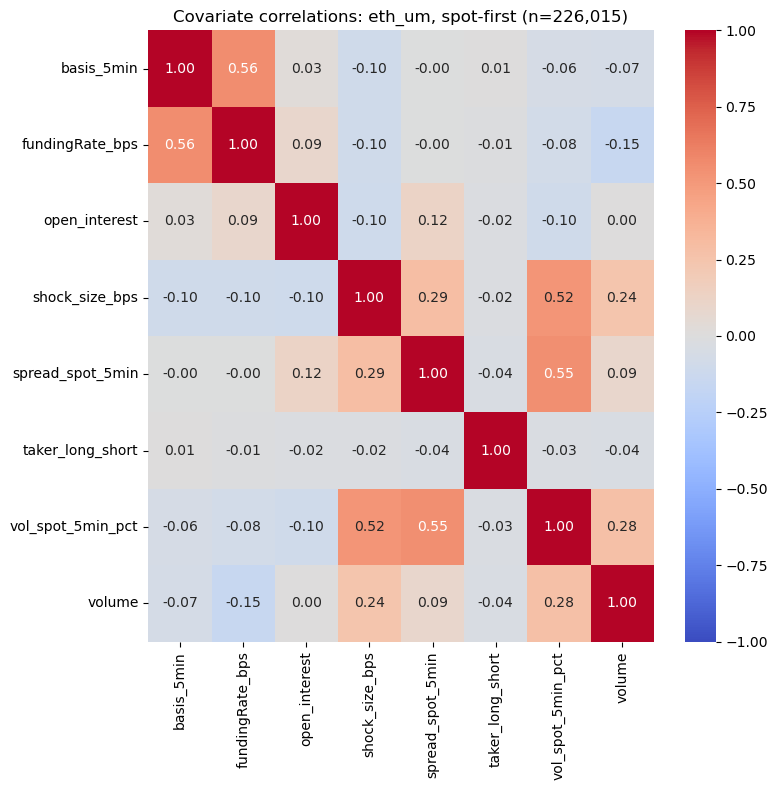

,market,first,covariate,VIF
6,eth_um,spot,vol_spot_5min_pct,1.917511
4,eth_um,spot,spread_spot_5min,1.518577
1,eth_um,spot,fundingRate_bps,1.494072
0,eth_um,spot,basis_5min,1.459130
3,eth_um,spot,shock_size_bps,1.398174
7,eth_um,spot,volume,1.132151
2,eth_um,spot,open_interest,1.071158
5,eth_um,spot,taker_long_short,1.003186


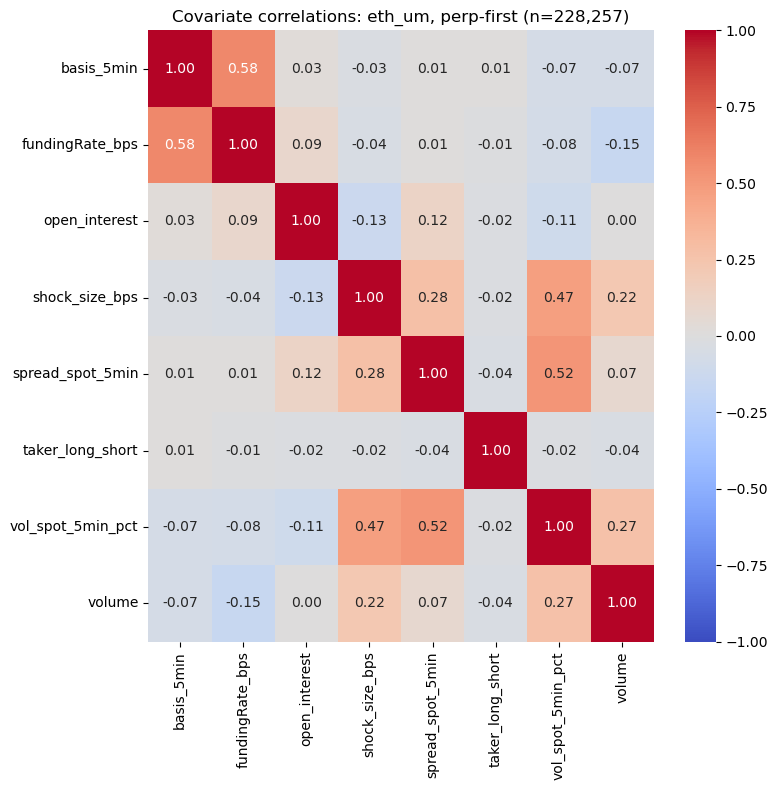

,market,first,covariate,VIF
6,eth_um,perp,vol_spot_5min_pct,1.751709
1,eth_um,perp,fundingRate_bps,1.562129
0,eth_um,perp,basis_5min,1.525622
4,eth_um,perp,spread_spot_5min,1.450315
3,eth_um,perp,shock_size_bps,1.321792
7,eth_um,perp,volume,1.129914
2,eth_um,perp,open_interest,1.080408
5,eth_um,perp,taker_long_short,1.003091


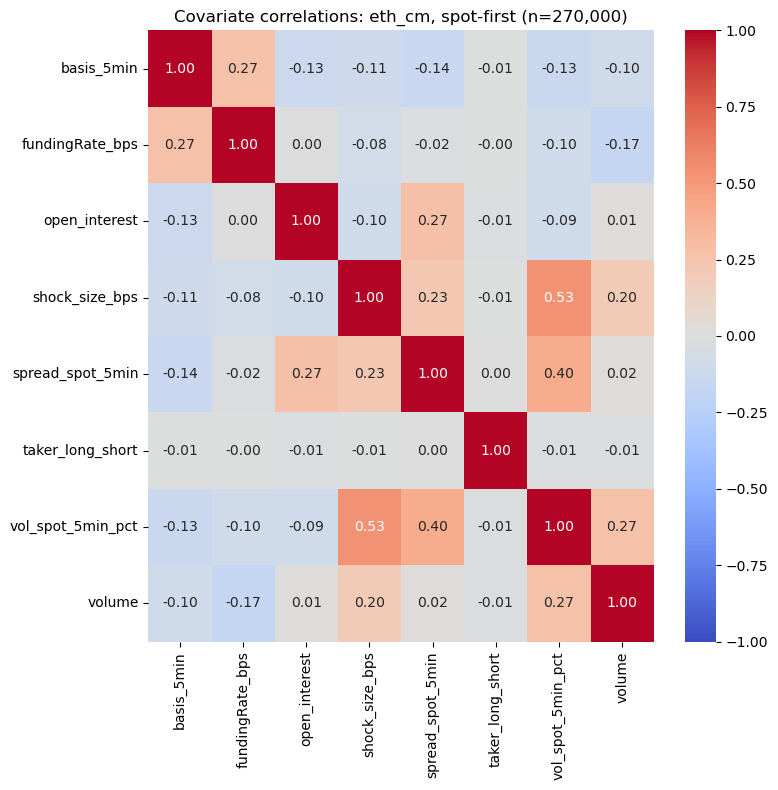

,market,first,covariate,VIF
6,eth_cm,spot,vol_spot_5min_pct,1.720518
3,eth_cm,spot,shock_size_bps,1.420929
4,eth_cm,spot,spread_spot_5min,1.377008
2,eth_cm,spot,open_interest,1.173991
7,eth_cm,spot,volume,1.127897
0,eth_cm,spot,basis_5min,1.122229
1,eth_cm,spot,fundingRate_bps,1.105666
5,eth_cm,spot,taker_long_short,1.000536


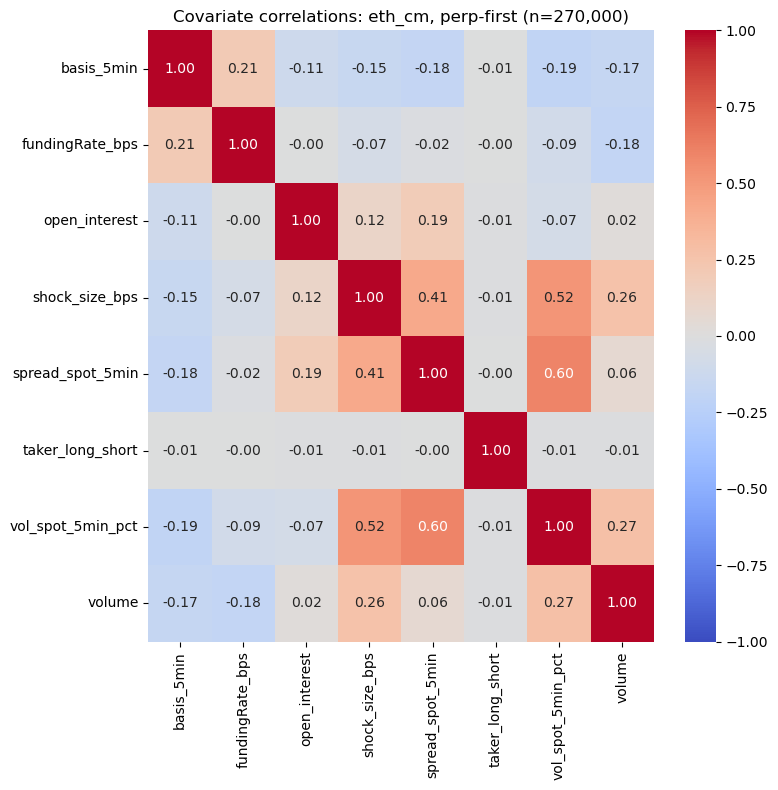

,market,first,covariate,VIF
6,eth_cm,perp,vol_spot_5min_pct,2.068850
4,eth_cm,perp,spread_spot_5min,1.771744
3,eth_cm,perp,shock_size_bps,1.470368
7,eth_cm,perp,volume,1.173120
2,eth_cm,perp,open_interest,1.136587
0,eth_cm,perp,basis_5min,1.112021
1,eth_cm,perp,fundingRate_bps,1.073169
5,eth_cm,perp,taker_long_short,1.000518


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Diagnose only the covariates included in the current AFT model.
DIAGNOSTIC_COVARIATES = [
    "basis_5min",
    "fundingRate_bps",
    "open_interest",
    "shock_size_bps",
    "spread_spot_5min",
    "taker_long_short",
    "vol_spot_5min_pct",
    "volume",
]
ROWS_PER_MONTH_DIRECTION = 5000  # balanced, memory-safe sample; use None for every row
RUN_MONTHLY_VIF = False
RANDOM_SEED = 2026

def finite_complete_numeric(frame, columns):
    available = [column for column in columns if column in frame.columns]
    out = frame[available].apply(pd.to_numeric, errors="coerce")
    return out.replace([np.inf, -np.inf], np.nan).dropna()

def calculate_vif(frame):
    # VIF is invariant to scaling, but standardization improves numerical stability.
    varying = [column for column in frame if frame[column].nunique(dropna=True) > 1]
    x = frame[varying].astype(float)
    x = (x - x.mean()) / x.std(ddof=0)
    x = x.replace([np.inf, -np.inf], np.nan).dropna()
    if x.empty or len(x) <= len(varying):
        return pd.DataFrame(columns=["covariate", "VIF"])
    values = x.to_numpy()
    return pd.DataFrame({
        "covariate": varying,
        "VIF": [variance_inflation_factor(values, i) for i in range(values.shape[1])],
    }).sort_values("VIF", ascending=False)

diagnostic_samples = {}
monthly_vif_rows = []
for market_name in SELECTED_MARKETS:
    input_dir = Path(MARKETS[market_name]["run_dir"]) / FINAL_LIQUIDITY_AFT_DIR
    for first in ("spot", "perp"):
        pieces = []
        for file_number, path in enumerate(sorted(input_dir.glob(f"{first}_*.parquet"))):
            frame = pd.read_parquet(path, columns=None)
            complete = finite_complete_numeric(frame, DIAGNOSTIC_COVARIATES)
            if ROWS_PER_MONTH_DIRECTION is not None and len(complete) > ROWS_PER_MONTH_DIRECTION:
                complete = complete.sample(
                    ROWS_PER_MONTH_DIRECTION,
                    random_state=RANDOM_SEED + file_number,
                )
            pieces.append(complete)

            if RUN_MONTHLY_VIF and not complete.empty:
                month_vif = calculate_vif(complete)
                month_vif["market"] = market_name
                month_vif["first"] = first
                month_vif["source_file"] = path.name
                month_vif_rows.append(month_vif)

            del frame, complete

        if not pieces:
            print(f"No files for {market_name} {first}")
            continue
        pooled = pd.concat(pieces, ignore_index=True).dropna()
        diagnostic_samples[(market_name, first)] = pooled
        del pieces

        corr = pooled.corr()
        fig_size = max(8, 0.7 * len(corr.columns))
        plt.figure(figsize=(fig_size, fig_size))
        sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f")
        plt.title(f"Covariate correlations: {market_name}, {first}-first (n={len(pooled):,})")
        plt.tight_layout()
        plt.show()

        vif = calculate_vif(pooled)
        vif.insert(0, "first", first)
        vif.insert(0, "market", market_name)
        display(vif)

if monthly_vif_rows:
    monthly_vif = pd.concat(monthly_vif_rows, ignore_index=True)
    display(
        monthly_vif.groupby(["market", "first", "covariate"])["VIF"]
        .agg(["median", "max", "count"])
        .reset_index()
        .sort_values(["market", "first", "max"], ascending=[True, True, False])
    )

## 7. Monthly AIC/BIC comparison across AFT distributions

This reads the saved fit manifests, selects the lowest-AIC and lowest-BIC distribution within each identical monthly event sample, plots the criteria over time, and summarizes how consistently each family wins.

In [ ]:
fit_frames = []
for market_name in SELECTED_MARKETS:
    manifest_path = (
        Path(MARKETS[market_name]["run_dir"])
        / FINAL_AFT_RESULTS_DIR
        / "aft_fit_manifest.csv"
    )
    if not manifest_path.exists():
        print(f"Missing fit manifest: {manifest_path}")
        continue
    frame = pd.read_csv(manifest_path)
    frame = frame[frame["status"].eq("complete")].copy()
    frame["market"] = market_name
    frame["first"] = frame["source_file"].str.extract(r"^(spot|perp)_", expand=False)
    frame["period"] = pd.to_datetime(
        frame["source_file"].str.extract(r"(\d{4}-\d{2})", expand=False),
        format="%Y-%m",
        errors="coerce",
    )
    fit_frames.append(frame)

monthly_fit = pd.concat(fit_frames, ignore_index=True) if fit_frames else pd.DataFrame()
if monthly_fit.empty:
    print("No completed AFT fit manifests found.")
else:
    comparison_keys = ["market", "first", "source_file", "period"]
    valid_groups = (
        monthly_fit.groupby(comparison_keys, dropna=False)
        .filter(lambda group: group["model"].nunique() == 3)
        .copy()
    )
    valid_groups["delta_AIC"] = valid_groups["AIC"] - valid_groups.groupby(comparison_keys)["AIC"].transform("min")
    valid_groups["delta_BIC"] = valid_groups["BIC"] - valid_groups.groupby(comparison_keys)["BIC"].transform("min")

    aic_winners = valid_groups.loc[valid_groups.groupby(comparison_keys)["AIC"].idxmin()].copy()
    bic_winners = valid_groups.loc[valid_groups.groupby(comparison_keys)["BIC"].idxmin()].copy()
    aic_winners = aic_winners.rename(columns={"model": "AIC_winner"})
    bic_winners = bic_winners.rename(columns={"model": "BIC_winner"})
    winners = aic_winners[comparison_keys + ["AIC_winner", "AIC"]].merge(
        bic_winners[comparison_keys + ["BIC_winner", "BIC"]],
        on=comparison_keys,
        validate="one_to_one",
    )
    winners["criteria_agree"] = winners["AIC_winner"].eq(winners["BIC_winner"])

    display(winners.sort_values(["market", "first", "period"]))
    display(
        winners.groupby(["market", "first", "AIC_winner"]).size()
        .rename("months_won_by_AIC").reset_index()
    )
    display(
        winners.groupby(["market", "first", "BIC_winner"]).size()
        .rename("months_won_by_BIC").reset_index()
    )
    print(f"AIC/BIC winner agreement: {winners['criteria_agree'].mean():.1%}")

    delta_summary = (
        valid_groups.groupby(["market", "first", "model"])[["delta_AIC", "delta_BIC"]]
        .agg(["mean", "median", "max"])
    )
    display(delta_summary)

    for (market_name, first), subset in valid_groups.groupby(["market", "first"]):
        fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        for model_name, model_rows in subset.groupby("model"):
            model_rows = model_rows.sort_values("period")
            axes[0].plot(model_rows["period"], model_rows["AIC"], label=model_name)
            axes[1].plot(model_rows["period"], model_rows["BIC"], label=model_name)
        axes[0].set_ylabel("AIC (lower is better)")
        axes[1].set_ylabel("BIC (lower is better)")
        axes[1].set_xlabel("Month")
        axes[0].set_title(f"Monthly AFT distribution comparison: {market_name}, {first}-first")
        for axis in axes:
            axis.grid(True, alpha=0.3)
            axis.legend()
        plt.tight_layout()
        plt.show()

## 8. Remove collinear covariates and refit only the AIC-selected family

This starts from the current eight-variable specification, repeatedly removes the largest unprotected VIF offender until the threshold is met across every market/direction diagnostic sample, selects the distribution with the **lowest** average monthly ΔAIC, and fits only that distribution. Lower—not higher—AIC is preferred.

In [ ]:
import gc
from lifelines import LogLogisticAFTFitter, LogNormalAFTFitter, WeibullAFTFitter
from survival_analysis_data_processing_final import prepare_aft_data

# -------------------------
# Editable specification
# -------------------------
VIF_STARTING_COVARIATES = [
    "basis_5min",
    "fundingRate_bps",
    "open_interest",
    "shock_size_bps",
    "spread_spot_5min",
    "taker_long_short",
    "vol_spot_5min_pct",
    "volume",
]
VIF_THRESHOLD = 5.0
VIF_PROTECTED_COVARIATES = {"shock_size_bps"}
VIF_FORCE_DROP = set()       # e.g. {"open_interest"}
VIF_FORCE_KEEP = set()       # additional variables the automatic loop may not remove
RUN_VIF_REDUCED_REFIT = False
VIF_REDUCED_RESULTS_DIR = "aft_results_vif_reduced"

if "diagnostic_samples" not in globals() or not diagnostic_samples:
    raise RuntimeError("Run Section 6 first to create the market/direction diagnostic samples.")
if "valid_groups" not in globals() or valid_groups.empty:
    raise RuntimeError("Run Section 7 first to load the completed monthly AIC results.")

# -------------------------
# Iterative VIF elimination
# -------------------------
reduced_covariates = [
    column for column in VIF_STARTING_COVARIATES
    if column not in VIF_FORCE_DROP
]
protected = set(VIF_PROTECTED_COVARIATES) | set(VIF_FORCE_KEEP)
vif_elimination_rows = []

while len(reduced_covariates) > 1:
    group_vifs = []
    for (market_name, first), sample in diagnostic_samples.items():
        missing = sorted(set(reduced_covariates) - set(sample.columns))
        if missing:
            raise KeyError(f"{market_name} {first} diagnostic sample is missing {missing}")
        group_vif = calculate_vif(sample[reduced_covariates].dropna())
        group_vif["market"] = market_name
        group_vif["first"] = first
        group_vifs.append(group_vif)

    all_group_vifs = pd.concat(group_vifs, ignore_index=True)
    worst_by_covariate = all_group_vifs.groupby("covariate")["VIF"].max().sort_values(ascending=False)
    removable = worst_by_covariate[~worst_by_covariate.index.isin(protected)]
    if removable.empty or float(removable.iloc[0]) <= VIF_THRESHOLD:
        break

    removed = str(removable.index[0])
    vif_elimination_rows.append({
        "step": len(vif_elimination_rows) + 1,
        "removed_covariate": removed,
        "worst_VIF_before_removal": float(removable.iloc[0]),
        "remaining_before_removal": list(reduced_covariates),
    })
    reduced_covariates.remove(removed)

final_vif_frames = []
for (market_name, first), sample in diagnostic_samples.items():
    frame = calculate_vif(sample[reduced_covariates].dropna())
    frame["market"] = market_name
    frame["first"] = first
    final_vif_frames.append(frame)
final_vif = pd.concat(final_vif_frames, ignore_index=True)

print("VIF-reduced covariates:", reduced_covariates)
display(pd.DataFrame(vif_elimination_rows))
display(final_vif.sort_values(["market", "first", "VIF"], ascending=[True, True, False]))

# -------------------------
# Select one distribution by the LOWEST average monthly delta AIC
# -------------------------
distribution_aic_summary = (
    valid_groups.groupby("model")["delta_AIC"]
    .agg(["mean", "median", "sum", "max", "count"])
    .sort_values(["mean", "sum"])
)
selected_aft_family = str(distribution_aic_summary.index[0])
display(distribution_aic_summary)
print("Selected AFT family (lowest mean delta AIC):", selected_aft_family)

AFT_FAMILY_CLASSES = {
    "weibull": WeibullAFTFitter,
    "lognormal": LogNormalAFTFitter,
    "loglogistic": LogLogisticAFTFitter,
}

# -------------------------
# Optional monthly refit of only the selected family
# -------------------------
reduced_fit_rows = []
if RUN_VIF_REDUCED_REFIT:
    fitter_class = AFT_FAMILY_CLASSES[selected_aft_family]
    for market_name in SELECTED_MARKETS:
        run_dir = Path(MARKETS[market_name]["run_dir"])
        input_dir = run_dir / FINAL_LIQUIDITY_AFT_DIR
        output_dir = run_dir / VIF_REDUCED_RESULTS_DIR / selected_aft_family / "coefficients"
        output_dir.mkdir(parents=True, exist_ok=True)

        for path in sorted(input_dir.glob("*.parquet")):
            model_data = fitter = None
            try:
                model_data, diagnostics = prepare_aft_data(path, reduced_covariates)
                if len(model_data) < MIN_COMPLETE_OBSERVATIONS:
                    reduced_fit_rows.append({
                        "market": market_name, "source_file": path.name,
                        "model": selected_aft_family,
                        "status": "skipped_too_few_observations", **diagnostics,
                    })
                    continue

                fitter = fitter_class()
                fitter.fit(model_data, duration_col="Length", event_col="Status", ancillary=False)
                coefficients = fitter.summary.reset_index()
                coefficients["market"] = market_name
                coefficients["source_file"] = path.name
                coefficients["model"] = selected_aft_family
                coefficients["covariates"] = "|".join(reduced_covariates)
                coefficients.to_csv(output_dir / f"{path.stem}_coefficients.csv", index=False)
                reduced_fit_rows.append({
                    "market": market_name, "source_file": path.name,
                    "model": selected_aft_family, "status": "complete",
                    "AIC": fitter.AIC_, "log_likelihood": fitter.log_likelihood_,
                    "concordance": fitter.concordance_index_,
                    "covariates": "|".join(reduced_covariates), **diagnostics,
                })
            except Exception as exc:
                reduced_fit_rows.append({
                    "market": market_name, "source_file": path.name,
                    "model": selected_aft_family, "status": "failed",
                    "error": repr(exc), "covariates": "|".join(reduced_covariates),
                })
            finally:
                del model_data, fitter
                gc.collect()

    reduced_fit_manifest = pd.DataFrame(reduced_fit_rows)
    for market_name, rows in reduced_fit_manifest.groupby("market"):
        result_dir = Path(MARKETS[market_name]["run_dir"]) / VIF_REDUCED_RESULTS_DIR
        result_dir.mkdir(parents=True, exist_ok=True)
        rows.to_csv(result_dir / "aft_fit_manifest.csv", index=False)
    display(reduced_fit_manifest)
else:
    print("Inspection only. Set RUN_VIF_REDUCED_REFIT = True to run the reduced monthly fits.")